# Part 1: Word2Vec Introduction

---

## The Problem with One-Hot Vectors

The classical way to represent words is using **one-hot vectors** a vector of size $|V| \times 1$ with a $1$ at the word's index and $0$ everywhere else.

Given a vocabulary:

$$\text{vocab} = [\texttt{king},\ \texttt{queen},\ \texttt{man},\ \texttt{woman},\ \texttt{dog}]$$

The encodings look like:

| Word  | king  | queen | man | woman | dog   |
| ----- | ----- | ----- | --- | ----- | ----- |
| king  | **1** | 0     | 0   | 0     | 0     |
| queen | 0     | **1** | 0   | 0     | 0     |
| dog   | 0     | 0     | 0   | 0     | **1** |

This representation has a **fundamental flaw** it hides meaning entirely. No matter how related two words are, the math never reflects it.


---

## Why One-Hot Vectors Fail

### 1. Cosine Similarity

Measures the angle between two vectors:

$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

For one-hot vectors:

$$\cos(\texttt{king},\ \texttt{queen}) = \frac{1 \times 0 + 0 \times 1 + \cdots}{1 \times 1} = 0$$

$$\cos(\texttt{king},\ \texttt{dog}) = 0$$

> Every pair gives **0** completely uninformative.

---

### 2. Euclidean Distance

Measures the straight-line distance between two vectors:

$$d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_i (a_i - b_i)^2}$$

For one-hot vectors:

$$d(\texttt{king},\ \texttt{queen}) = \sqrt{2} \approx 1.414$$

$$d(\texttt{king},\ \texttt{dog}) = \sqrt{2} \approx 1.414$$

> Every pair gives the **same distance** again, completely uninformative.


---

## Conclusion

**king vs queen** is indistinguishable from **king vs dog**.

One-hot representations carry **zero semantic information** they tell us nothing about how words relate to each other. This motivates the need for dense, learned embeddings like Word2Vec.


---

## Word Embeddings: The Core Idea

Instead of hand-crafting representations, we **learn** a dense vector for each word directly from text.

The guiding principle is the **distributional hypothesis**:

> _Words that appear in similar contexts tend to have similar meanings._

So rather than assigning a fixed slot in a one-hot vector, each word gets a **learned embedding** a dense vector of real numbers, typically of dimension $d \in \{50, 100, 300\}$:

$$\text{king} \rightarrow \mathbf{e}_{\text{king}} = [0.72,\ -0.39,\ 0.15,\ \ldots] \in \mathbb{R}^d$$

These vectors are **not designed** they emerge from training. Words that co-occur in similar contexts gets closer to each other in the embedding space until the geometry reflects meaning.

> at the end we reach our goal when we find that similar words have their embeddings close to each other in the embedding space (clustering similar words together )


## Step 1: Install & Import Libraries

We install the `datasets` library from HuggingFace to load CoNLL-2003.


In [2]:
!pip install datasets

import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from datasets import load_dataset
import matplotlib.pyplot as plt

https://huggingface.co/datasets/lhoestq/conll2003/viewer


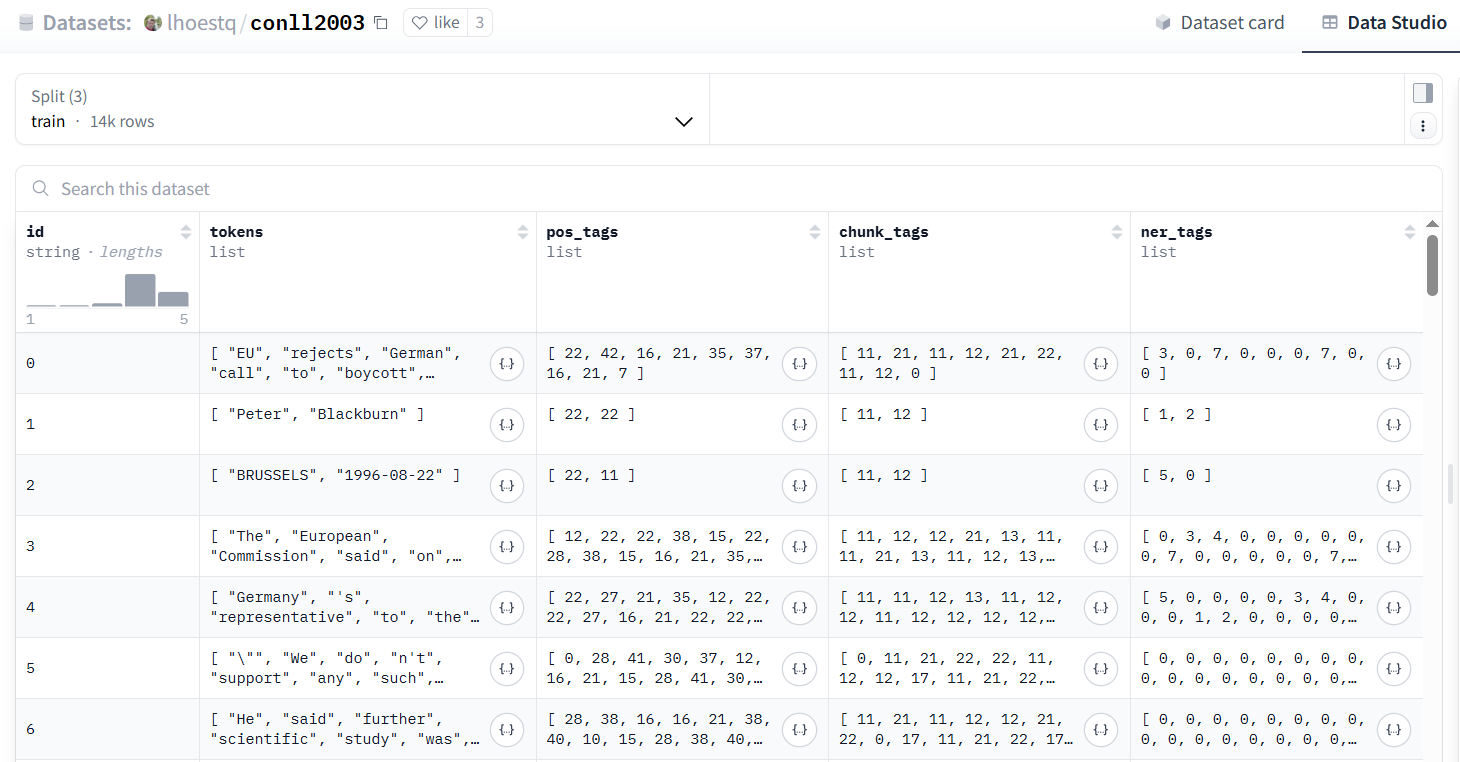


## Step 2: Load the Dataset

CO-NLL structure


In [3]:
dataset = load_dataset("lhoestq/conll2003")
print(dataset)
print(dataset["train"])
print("\nSample sentence:", dataset["train"][0]["tokens"])
print("Sample NER tags:", dataset["train"][0]["ner_tags"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
Dataset({
    features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
    num_rows: 14041
})

Sample sentence: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Sample NER tags: [3, 0, 7, 0, 0, 0, 7, 0, 0]


## Step 3: Extract & Preprocess Text

We extract the `tokens` field from all three splits (train, validation, test)
and combine them into one big corpus for Word2Vec training.

Preprocessing steps applied to each token:

- **Lowercase** so "The" and "the" are treated as the same word
- **Remove punctuation-only tokens** tokens like "." or "," carry no semantic meaning


In [4]:
def clean_line(text):
    text = text.lower()
    # keep only letters and spaces; everything else -> space
    text = "".join(ch if ch.isalpha() or ch == " " else " " for ch in text)
    return text.split()  # returns list of tokens


def preprocessing(dataset):
    # Extract from all splits
    sentences = []
    n = len(dataset["train"]) + len(dataset["validation"]) + len(dataset["test"])
    for i in range(len(dataset["train"])):
        sentences.append(dataset["train"][i])
    for i in range(len(dataset["validation"])):
        sentences.append(dataset["validation"][i])
    for i in range(len(dataset["test"])):
        sentences.append(dataset["test"][i])

    # Apply preprocessing
    corpus = []
    for i in range(len(sentences)):
        # ["tokens"] gets the sentences attribute out of the dict
        # we joined because in co nll the sentence is pre tokenized so i have to pass it as
        # as sentence into clean line to lower and check characters in the sentence
        cleaned = clean_line(" ".join(sentences[i]["tokens"]))
        if not cleaned:  # skip sentences that became empty after cleaning
            continue
        corpus.append(cleaned)
    return corpus


corpus = preprocessing(dataset)
print(f"corpus: {corpus}")
print(f"Total sentences: {len(corpus)}")
print(f"Sample cleaned sentence: {corpus[0]}")

corpus: [['eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb'], ['peter', 'blackburn'], ['brussels'], ['the', 'european', 'commission', 'said', 'on', 'thursday', 'it', 'disagreed', 'with', 'german', 'advice', 'to', 'consumers', 'to', 'shun', 'british', 'lamb', 'until', 'scientists', 'determine', 'whether', 'mad', 'cow', 'disease', 'can', 'be', 'transmitted', 'to', 'sheep'], ['germany', 's', 'representative', 'to', 'the', 'european', 'union', 's', 'veterinary', 'committee', 'werner', 'zwingmann', 'said', 'on', 'wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer'], ['we', 'do', 'n', 't', 'support', 'any', 'such', 'recommendation', 'because', 'we', 'do', 'n', 't', 'see', 'any', 'grounds', 'for', 'it', 'the', 'commission', 's', 'chief', 'spokesman', 'nikolaus', 'van', 'der', 'pas', 'told', 'a', 'news', 'briefing'], ['he', 'said', 'further', 'scientific', 'study', '

calling preprocessing would return a corpus that is a list of lists each list have the tokens in a specific sentence


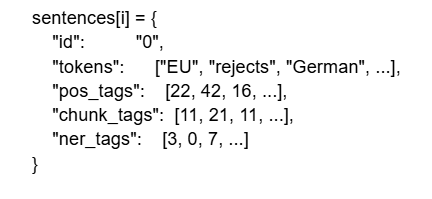


# Step 4: Build Vocab


**_Step 4.1:_**

Remove rare words because it adds noise, and a word that appears rarely we wont learn a good embedding for.

**_The vocabulary (word->count)_**


In [5]:
def filter(minFreq=2):
    word_counts = {}

    # Counts how many times each word appeard
    for sentence in corpus:
        for word in sentence:
            if word in word_counts:
                word_counts[word] += 1
            # first time to see it set to 1
            else:
                word_counts[word] = 1
    filtered_words = {}
    for word, count in word_counts.items():
        if count >= minFreq:
            filtered_words[word] = count
    # Also clean the corpus remove rare words from sentences in the corpus
    filtered_corpus = []
    for sentence in corpus:
        clean_sentence = [word for word in sentence if word in filtered_words]
        if clean_sentence:  # skip if sentence became empty
            filtered_corpus.append(clean_sentence)

    return filtered_words, filtered_corpus

In [6]:
filtered_words, filtered_corpus = filter()


def build_vocab(filtered_words):
    word2idx = {}
    idx2word = {}

    idx = 0
    for word in filtered_words:
        word2idx[word] = idx
        idx2word[idx] = word
        idx += 1

    vocab_size = len(word2idx)
    print(f"Vocabulary size: {vocab_size}")

    return word2idx, idx2word, vocab_size


word2idx, idx2word, VOCAB_SIZE = build_vocab(filtered_words)

Vocabulary size: 12113


filtered_words → the vocabulary (word → count)

word2idx → the vocabulary (word → index)

Purpose → when we have a word and need its number to look up its row in the embedding matrix V

idx2word → the vocabulary (index → word)

Purpose → the exact reverse when we have a number and need to know what word it represents. We need this for the analogy function at the end the model outputs an index and we need to convert it back to a readable word.


word2idx = {
"eu": 0,
"rejects": 1,
"german": 2,
"call": 3,
...
}

idx2word = {
0: "eu",
1: "rejects",
2: "german",
3: "call",
...
}


## Step 5: Skip-Gram with Negative Sampling (SGNS)

### The Goal Maximize Log-Likelihood

For each center word $w$ and its positive context $c_{pos}$, we want to maximize:

$$\mathcal{L} = \sum_{(w, c_{pos})} \left[ \log P(x=1 | w, c_{pos}) + \sum_{k=1}^{K} \log P(x=0 | w, c_{neg_k}) \right]$$

- **Maximize** the probability that $(w, c_{pos})$ is a real pair $\rightarrow P(x=1)$
- **Maximize** the probability that $(w, c_{neg})$ is a real negative pair $\rightarrow P(x=0)$

---

Generally said is that the probability is the sigmoid of the similarity between the 2 vectors (and this similarity is measured using dot product)

### What is $P(x=1 \mid w, c)$?

$$P(x=1 \mid w, c) = \sigma(\mathbf{v}_w \cdot \mathbf{u}_c)$$

Where:

- $\mathbf{v}_w$ → embedding of the **center word** (from embedding matrix $V$)
- $\mathbf{u}_c$ → embedding of the **context word** (from embedding matrix $U$)
- $\sigma$ → sigmoid function → squashes dot product to $[0,1]$

And naturally:

$$P(x=0 \mid w, c) = 1 - \sigma(\mathbf{v}_w \cdot \mathbf{u}_c) = \sigma(-\mathbf{v}_w \cdot \mathbf{u}_c)$$

---

### Full Objective Per Training Pair

$$\mathcal{L}(w, c_{pos}) = \log \sigma(\mathbf{v}_w \cdot \mathbf{u}_{c_{pos}}) + \sum_{k=1}^{K} \log \sigma(-\mathbf{v}_w \cdot \mathbf{u}_{c_{neg_k}})$$

We want to **maximize** $\mathcal{L}$ → so we **minimize** the negative:

$$\mathcal{J} = -\log \sigma(\mathbf{v}_w \cdot \mathbf{u}_{c_{pos}}) - \sum_{k=1}^{K} \log \sigma(-\mathbf{v}_w \cdot \mathbf{u}_{c_{neg_k}})$$

---

### The Two Embedding Matrices

We maintain **two separate matrices**:

| Matrix | Role                    | Shape                        |
| ------ | ----------------------- | ---------------------------- |
| $V$    | Center word embeddings  | $[\text{V} \times \text{d}]$ |
| $U$    | Context word embeddings | $[\text{V} \times \text{d}]$ |

Every word has **two vectors** one when it appears as a center word, one when it appears as a context word. At the end we use $V$ alone as our final embeddings or sometimes some people use V + U but the matrix made for the center words must be there and we don't care about the classification (logistic regression) itself we care about the weights learnt.

---

### $K$: Number of Negative Samples (Hyperparameter)

$K$ is the number of negative samples per positive pair:

- Small dataset $\rightarrow K = 5$ to $20$
- Large dataset $\rightarrow K = 2$ to $5$

---

### How Do We Sample $c_{neg}$?

We sample from the vocabulary using a **modified unigram distribution**:

$$P(w) = \frac{f(w)^{3/4}}{\sum_{j} f(j)^{3/4}}$$

Where $f(w)$ is the word frequency. The $3/4$ power:

- Reduces the dominance of very frequent words like _"the"_, _"a"_
- Gives rare words a slightly higher chance of being sampled
- Negative samples must **not** be actual context words of the center word


## Hyperparameters

- Data
  MIN_FREQ = 2  
  minimum word frequency to keep in vocabulary

- Skip-Gram
  WINDOW_SIZE = 2  
   number of words to look left and right

- Embeddings
  EMB_DIM = 100  
  size of each word embedding vector

- Negative Sampling
  K = 5  
   number of negative samples per positive pair

- Training
  LEARNING_RATE = 0.01 ,
  EPOCHS = 5


In [7]:
def generate_pairs(corpus, word2idx, window_size=2):

    pairs = []
    # looping over all sentences in the corpus
    for sentence in corpus:

        # convert words to indices (According to their position in the vocabulary: because that is how we will lookup for them in the embedding vectors)
        sentence_idx = []
        # looping over words in the sentence and changing every one of them to an index using the dict or word2idx
        for word in sentence:
            if word in word2idx:
                sentence_idx.append(word2idx[word])

        # slide over each position
        for center_pos in range(len(sentence_idx)):
            # get the center index
            center_idx = sentence_idx[center_pos]

            for offset in range(-window_size, window_size + 1):

                # skip center word itself
                if offset == 0:
                    continue

                context_pos = center_pos + offset

                # skip if out of bounds
                if context_pos < 0 or context_pos >= len(sentence_idx):
                    continue

                context_idx = sentence_idx[context_pos]
                pairs.append((center_idx, context_idx))

    return pairs


pairs = generate_pairs(filtered_corpus, word2idx)

print(f"Total training pairs: {len(pairs)}")
print(f"Sample pair indices:  {pairs[0]}")
print(f"Sample pair words:    ({idx2word[pairs[0][0]]}, {idx2word[pairs[0][1]]})")

Total training pairs: 806826
Sample pair indices:  (0, 1)
Sample pair words:    (eu, rejects)


## Step 6: 6.1. Build Negative Sampling Distribution

For each positive pair (center, context) we need to sample K negative words.
We sample using a modified unigram distribution:

$$P(w) = \frac{f(w)^{3/4}}{\sum_{j} f(j)^{3/4}}$$

The $3/4$ power reduces the dominance of very frequent words and gives
rare words a slightly higher chance of being sampled.


In [8]:
import numpy as np


def build_noise_distribution(filtered_words, word2idx):

    # create an array of zeros of size VOCAB_SIZE
    word_freqs = np.zeros(len(word2idx))

    # fill in the frequency of each word at its vocab index
    for word, count in filtered_words.items():
        idx = word2idx[word]
        word_freqs[idx] = count

    # raise to the power of 3/4
    word_freqs = word_freqs**0.75

    # normalize to get probabilities (all values sum to 1)
    word_freqs = word_freqs / word_freqs.sum()

    return word_freqs


# a list that have the probability of all the words but raised to the power of 3/4
noise_dist = build_noise_distribution(filtered_words, word2idx)

## Step 6: 6.2. Sample Negative Words

For each positive pair (center, context_pos) we sample K words
that did NOT appear in the context of the center word.

We use the noise distribution we built to sample frequent words
have higher probability of being picked as negatives.

We must make sure the sampled negative is not the actual context word.


In [9]:
def get_negatives(center_idx, context_idx, noise_dist, k):

    negatives = []
    # k is set to 2 but can be tuned
    while len(negatives) < k:

        # sample one word index according to noise distribution
        # pick a random number from 0 to vocab size but makes the randomness weighted by the noise_dist
        neg_idx = np.random.choice(VOCAB_SIZE, p=noise_dist)

        # make sure it is not the actual context word
        # or the center word itself
        if neg_idx != context_idx and neg_idx != center_idx:
            negatives.append(neg_idx)

    return negatives

## Step 7: The SGNS Model

We have two embedding matrices:

- `V` → center word embeddings shape: [V × d]
- `U` → context word embeddings shape: [V × d]

Both are initialized with small random values.

For each training pair (center, context_pos, negatives):

1. Look up `v_w` = V[center_idx]
2. Look up `u_pos` = U[context_idx]
3. Look up `u_negs` = U[neg_indices]
4. Compute loss J:

$$\mathcal{J} = -\log \sigma(v_w \cdot u_{pos}) - \sum_{k=1}^{K} \log \sigma(-v_w \cdot u_{neg_k})$$

5. Backpropagate → update V and U


In [10]:
import torch
import torch.nn as nn


class SGNS(nn.Module):

    def __init__(self, vocab_size, emb_dim):
        super(SGNS, self).__init__()

        # creates the center word embedding matrix vxd
        self.V = nn.Embedding(vocab_size, emb_dim)

        # creates the context word embedding matrix vxd
        self.U = nn.Embedding(vocab_size, emb_dim)

        # initialize both with small random values bet -0.1 : 0.1
        nn.init.uniform_(self.V.weight, -0.1, 0.1)
        nn.init.uniform_(self.U.weight, -0.1, 0.1)

    # runs when we call model(center,context,negs)
    def forward(self, center_idx, context_idx, neg_indices):

        # look up embeddings
        v_w = self.V(center_idx)  # dx1
        u_pos = self.U(context_idx)  # dx1
        u_negs = self.U(neg_indices)  # kxd

        pos_score = (v_w * u_pos).sum(dim=1)
        pos_loss = torch.log(torch.sigmoid(pos_score)).mean()

        neg_score = torch.bmm(u_negs, v_w.unsqueeze(2)).squeeze(2)
        neg_loss = torch.log(torch.sigmoid(-neg_score)).sum(dim=1).mean()

        # total loss (we minimize negative of objective)
        loss = -(pos_loss + neg_loss)

        return loss

PyTorch automatically computes gradients and updates weights only write the forward pass and it handles the rest.
.. it gets the backward pass itself only from the loss function u wrote in forward pass


> _For a positive pair (real context word):_

_we want v_w · u_pos to be HIGH_

- sigmoid(v_w · u_pos) close to 1

- log(sigmoid(v_w · u_pos)) close to 0
- loss is small

> _For a negative pair (fake context word):_

we want v_w · u_neg to be LOW

- -(v_w · u_neg) is HIGH

- sigmoid(-(v_w · u_neg)) close to 1

- log(sigmoid(-(v_w · u_neg))) close to 0

- loss is small


## Step 8: Training Loop

We loop over all pairs for each epoch:

1. Get the positive pair (center, context)
2. Sample K negative words
3. Compute the loss J
4. Backpropagate → update V and U
5. Monitor loss per epoch


Using: cuda
Epoch 1/10 → Loss: 2.6071
Epoch 2/10 → Loss: 2.1200
Epoch 3/10 → Loss: 1.9284
Epoch 4/10 → Loss: 1.7977
Epoch 5/10 → Loss: 1.7001
Epoch 6/10 → Loss: 1.6301
Epoch 7/10 → Loss: 1.5767
Epoch 8/10 → Loss: 1.5350
Epoch 9/10 → Loss: 1.5028
Epoch 10/10 → Loss: 1.4764


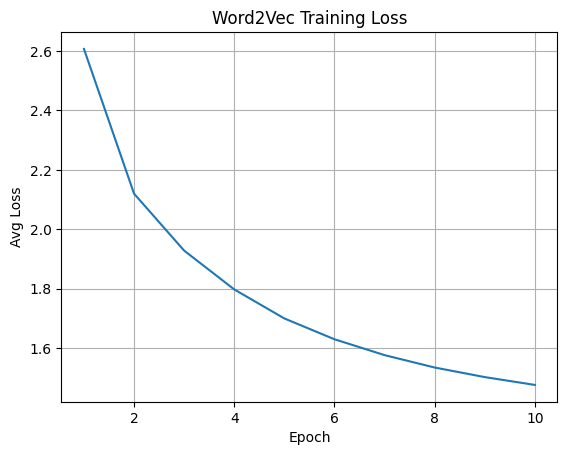

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

K = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
# Pre-convert pairs to tensors once before loop
centers = torch.tensor([p[0] for p in pairs])
contexts = torch.tensor([p[1] for p in pairs])

model = SGNS(VOCAB_SIZE, 100)
optimizer = optim.Adam(model.parameters(), lr=0.001)

prev_loss = float("inf")
tolerance = 1e-4
loss_history = []

for epoch in range(10):

    all_negs = torch.tensor(
        [
            get_negatives(c.item(), ctx.item(), noise_dist, K)
            for c, ctx in zip(centers, contexts)
        ]
    )

    dataset = TensorDataset(centers, contexts, all_negs)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    total_loss = 0
    for center_batch, context_batch, neg_batch in dataloader:
        loss = model(center_batch, context_batch, neg_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/10 → Loss: {avg_loss:.4f}")

    if abs(prev_loss - avg_loss) < tolerance:
        print("Converged.")
        break
    prev_loss = avg_loss

# plot loss
plt.plot(range(1, len(loss_history) + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Avg Loss")
plt.title("Word2Vec Training Loss")
plt.grid(True)
plt.show()

## Step 9: Save Embeddings


In [15]:
torch.save(model.V.weight.data, "embeddings.pt")
# saved vocabulary
import pickle

with open("word2idx.pkl", "wb") as f:
    pickle.dump(word2idx, f)

with open("idx2word.pkl", "wb") as f:
    pickle.dump(idx2word, f)

In [ ]:
# model.V = nn.Embedding(vocab_size, emb_dim)
# This is just a container around a tensor.
# Inside it:
# model.V.weight  ≈  V (your matrix) this is used by pytorch to track the gradients in backpropagation
# meanwhile we use .data which means we only need V the final V after training